In [1]:
import os
import cv2
import glob
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                     Conv2DTranspose, concatenate, 
                                     BatchNormalization, Activation, add,
                                     MultiHeadAttention, LayerNormalization, Dense, Reshape,
                                     GlobalAveragePooling2D, Multiply)
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow.keras.backend as K
from sklearn.model_selection import KFold

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')


SEED_VALUE = 24

def set_global_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_global_seed(SEED_VALUE)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(f"Global Seed is strictly locked to: {SEED_VALUE}")


IMG_HEIGHT = 256  
IMG_WIDTH = 256   
N_CHANNELS = 1         # Ảnh huỳnh quang (Grayscale)
BATCH_SIZE = 8         # Phù hợp tập dữ liệu 97 ảnh
EPOCHS = 150           
N_SPLITS = 5           
RANDOM_STATE = SEED_VALUE  
LEARNING_RATE = 1e-3   
ALPHA = 1.67

2026-05-05 14:59:48.204152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777993188.395105      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777993188.448951      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777993188.908015      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777993188.908051      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777993188.908054      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Num GPUs Available: 1
Global Seed is strictly locked to: 24


In [2]:
base_path = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/ISBI2009"
img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "masks")

def load_isbi2009_data():
    X, Y = [], []
    img_files = sorted(glob.glob(os.path.join(img_dir, "*.*")))
    
    if len(img_files) == 0:
        raise ValueError("Không tìm thấy ảnh nào. Vui lòng kiểm tra lại đường dẫn base_path!")
        
    print(f"\nĐang nạp {len(img_files)} ảnh từ ISBI-2009...")
    for f in tqdm(img_files, desc="Loading Images"):
        filename = os.path.basename(f)
        m_path = os.path.join(mask_dir, filename)
        if os.path.exists(m_path):
            # Xử lý ảnh Input
            img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
            X.append(img)
            
            # Xử lý Mask (Ground Truth)
            msk = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
            msk = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
            Y.append(np.round(msk, 0))
            
    return np.expand_dims(np.array(X), -1), np.expand_dims(np.array(Y), -1)

try:
    X, Y = load_isbi2009_data()
    print(f"Dữ liệu sẵn sàng! X shape: {X.shape}, Y shape: {Y.shape}")
except Exception as e:
    print(f" {e}")
    print("Tạo dữ liệu giả lập để test code...")
    X = np.random.rand(30, IMG_HEIGHT, IMG_WIDTH, 1)
    Y = np.random.randint(0, 2, (30, IMG_HEIGHT, IMG_WIDTH, 1))


Đang nạp 97 ảnh từ ISBI-2009...


Loading Images: 100%|██████████| 97/97 [00:02<00:00, 33.36it/s]

Dữ liệu sẵn sàng! X shape: (97, 256, 256, 1), Y shape: (97, 256, 256, 1)


In [3]:
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def ea_ftl_loss(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1.0 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1.0 - y_pred_f))
    
    alpha_t = 0.3
    beta_t = 0.7
    gamma_t = 4./3.
    
    tversky = (tp + K.epsilon()) / (tp + alpha_t * fp + beta_t * fn + K.epsilon())
    ftl = K.pow((1.0 - tversky), gamma_t)
    
    y_true_edges = tf.image.sobel_edges(y_true)
    y_pred_edges = tf.image.sobel_edges(y_pred)
    edge_loss = K.mean(K.abs(y_true_edges - y_pred_edges))
    
    return ftl + 0.5 * edge_loss

def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1), activation='relu'):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    if activation is not None:
        x = Activation(activation)(x)
    return x

In [4]:
# ============================================================================
# 4. KIẾN TRÚC 1: BASELINE MULTIRES-UNET
# ============================================================================
def build_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def MultiResBlock_base(U, inp): 
        W = ALPHA * U
        short = conv2d_bn(inp, int(W*0.167)+int(W*0.333)+int(W*0.5), 1, 1, activation=None)
        c3 = conv2d_bn(inp, int(W*0.167), 3, 3); c5 = conv2d_bn(c3, int(W*0.333), 3, 3); c7 = conv2d_bn(c5, int(W*0.5), 3, 3)
        return Activation('relu')(add([short, concatenate([c3, c5, c7], 3)]))

    def ResPath_base(f, length, inp): 
        out = conv2d_bn(inp, f, 3, 3)
        out = add([conv2d_bn(inp, f, 1, 1, activation=None), out])
        out = Activation('relu')(BatchNormalization(axis=3)(out))
        for _ in range(length - 1):
            short = conv2d_bn(out, f, 1, 1, activation=None)
            out = conv2d_bn(out, f, 3, 3)
            out = Activation('relu')(add([short, out]))
            out = BatchNormalization(axis=3)(out)
        return out

    inputs = Input((height, width, n_channels))
    m1 = MultiResBlock_base(32, inputs); p1 = MaxPooling2D((2,2))(m1); r1 = ResPath_base(32, 4, m1)
    m2 = MultiResBlock_base(64, p1); p2 = MaxPooling2D((2,2))(m2); r2 = ResPath_base(64, 3, m2)
    m3 = MultiResBlock_base(128, p2); p3 = MaxPooling2D((2,2))(m3); r3 = ResPath_base(128, 2, m3)
    m4 = MultiResBlock_base(256, p3); p4 = MaxPooling2D((2,2))(m4); r4 = ResPath_base(256, 1, m4)
    m5 = MultiResBlock_base(512, p4)
    
    u6 = concatenate([Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(m5), r4], 3); m6 = MultiResBlock_base(256, u6)
    u7 = concatenate([Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_base(128, u7)
    u8 = concatenate([Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_base(64, u8)
    u9 = concatenate([Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_base(32, u9)
    return Model(inputs, Conv2D(1, (1,1), activation='sigmoid')(m9), name='Baseline_MultiResUNet')

# ============================================================================
# 5. KIẾN TRÚC 2: HTS-MULTIRESUNET
# ============================================================================
def squeeze_excite_block(inputs, ratio=8):
    c = K.int_shape(inputs)[3]
    x = GlobalAveragePooling2D()(inputs)
    x = Reshape((1, 1, c))(x)
    x = Dense(c // ratio, activation='relu', use_bias=False)(x)
    x = Dense(c, activation='sigmoid', use_bias=False)(x)
    return Multiply()([inputs, x])

def TransformerBlock(inputs, num_heads=8, embed_dim=64, ff_dim=1024):
    shape = K.int_shape(inputs); h, w, c = shape[1], shape[2], shape[3]
    x = Reshape((h * w, c))(inputs)
    attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = LayerNormalization(epsilon=1e-6)(add([x, attn_out]))
    ffn_out = Dense(c)(Dense(ff_dim, activation='relu')(x))
    return Reshape((h, w, c))(LayerNormalization(epsilon=1e-6)(add([x, ffn_out])))

def build_hts_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def MultiResBlock_hts(U, inp):
        W = ALPHA * U
        shortcut = conv2d_bn(inp, int(W*0.167)+int(W*0.333)+int(W*0.5), 1, 1, activation=None)
        c3 = conv2d_bn(inp, int(W*0.167), 3, 3); c5 = conv2d_bn(c3, int(W*0.333), 3, 3); c7 = conv2d_bn(c5, int(W*0.5), 3, 3)
        out = BatchNormalization(axis=3)(concatenate([c3, c5, c7], 3))
        out = BatchNormalization(axis=3)(Activation('relu')(add([shortcut, out])))
        return squeeze_excite_block(out)

    def ResPath_hts(f, length, inp):
        out = conv2d_bn(inp, f, 3, 3)
        out = Activation('relu')(BatchNormalization(axis=3)(add([conv2d_bn(inp, f, 1, 1, activation=None), out])))
        for _ in range(length - 1):
            short = conv2d_bn(out, f, 1, 1, activation=None)
            out = BatchNormalization(axis=3)(Activation('relu')(add([short, conv2d_bn(out, f, 3, 3)])))
        return squeeze_excite_block(out)

    inputs = Input((height, width, n_channels))
    m1 = MultiResBlock_hts(32, inputs); p1 = MaxPooling2D((2,2))(m1); r1 = ResPath_hts(32, 4, m1)
    m2 = MultiResBlock_hts(64, p1); p2 = MaxPooling2D((2,2))(m2); r2 = ResPath_hts(64, 3, m2)
    m3 = MultiResBlock_hts(128, p2); p3 = MaxPooling2D((2,2))(m3); r3 = ResPath_hts(128, 2, m3)
    m4 = MultiResBlock_hts(256, p3); p4 = MaxPooling2D((2,2))(m4); r4 = ResPath_hts(256, 1, m4)
    
    m5 = MultiResBlock_hts(512, p4)
    trans_bottleneck = TransformerBlock(m5)
    
    u6 = concatenate([Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(trans_bottleneck), r4], 3); m6 = MultiResBlock_hts(256, u6)
    u7 = concatenate([Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock_hts(128, u7)
    u8 = concatenate([Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock_hts(64, u8)
    u9 = concatenate([Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock_hts(32, u9)
    return Model(inputs, Conv2D(1, (1,1), activation='sigmoid')(m9), name='HTS_MultiResUNet')

In [5]:
def draw_mask_contour(img_rgb, mask, color, thickness=1):
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_with_contour = img_rgb.copy()
    cv2.drawContours(img_with_contour, contours, -1, color, thickness)
    return img_with_contour

def show_comparison_demo(X_test, Y_test, model_base, model_hts, num_samples=3):
    print("\nĐang tạo ảnh Demo Comparison (Overlay 2 mô hình)...")
    yp_base = np.round(model_base.predict(X_test, verbose=0), 0)
    yp_hts = np.round(model_hts.predict(X_test, verbose=0), 0)
    
    COLOR_GT = (0, 255, 0)      # Xanh lục (Ground Truth)
    COLOR_BASE = (255, 0, 0)    # Đỏ (Baseline MultiResUNet)
    COLOR_HTS = (0, 0, 255)     # Xanh dương (HTS-MultiResUNet)
    
    num_samples = min(num_samples, len(X_test))
    
    for i in range(num_samples):
        # Tạo khung hình 5 cột
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        img_gray = (X_test[i].squeeze() * 255).astype(np.uint8)
        img_rgb_base = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
        
        # 1. Input Image
        axes[0].imshow(img_gray, cmap='gray')
        axes[0].set_title('Input Image', fontsize=14); axes[0].axis('off')
        
        # 2. Ground Truth
        axes[1].imshow(Y_test[i].squeeze(), cmap='gray')
        axes[1].set_title('Ground Truth', fontsize=14); axes[1].axis('off')
        
        # 3. Baseline Mask
        axes[2].imshow(yp_base[i].squeeze(), cmap='gray')
        axes[2].set_title('Baseline MultiResUNet', fontsize=14); axes[2].axis('off')

        # 4. HTS Mask
        axes[3].imshow(yp_hts[i].squeeze(), cmap='gray')
        axes[3].set_title('HTS-MultiResUNet', fontsize=14); axes[3].axis('off')
        
        # 5. Overlay Comparison (Chồng 2 viền lên nhau)
        comp_img = img_rgb_base.copy()
        comp_img = draw_mask_contour(comp_img, Y_test[i].squeeze(), COLOR_GT, 1)    # Viền xanh lục cho GT
        comp_img = draw_mask_contour(comp_img, yp_base[i].squeeze(), COLOR_BASE, 1) # Viền đỏ cho Baseline
        comp_img = draw_mask_contour(comp_img, yp_hts[i].squeeze(), COLOR_HTS, 1)   # Viền xanh dương cho HTS
        
        axes[4].imshow(comp_img)
        axes[4].set_title('Overlay Comparison', fontsize=14); axes[4].axis('off')
        
        gt_patch = mpatches.Patch(color=[c/255 for c in COLOR_GT], label='Ground Truth')
        base_patch = mpatches.Patch(color=[c/255 for c in COLOR_BASE], label='Baseline MultiResUNet')
        hts_patch = mpatches.Patch(color=[c/255 for c in COLOR_HTS], label='HTS-MultiResUNet')
        axes[4].legend(handles=[gt_patch, base_patch, hts_patch], loc='upper right', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'Demo_Comparison_Overlay_{i+1}.png', dpi=300)
        plt.show()

In [6]:
print("\n" + "="*60)
print("  BẮT ĐẦU ABLATION STUDY TRÊN ISBI-2009 (5-FOLD CV)")
print("  So sánh: Baseline MultiResUNet vs HTS-MultiResUNet")
print("="*60)

os.makedirs('models_isbi2009', exist_ok=True)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Khởi tạo danh sách lưu kết quả
jac_base, dice_base, hist_base_list = [], [], []
jac_hts, dice_hts, hist_hts_list = [], [], []
best_fold_idx = 0
best_hts_jaccard = 0

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f"\n" + "-"*40)
    print(f"  ĐANG XỬ LÝ FOLD {fold}/{N_SPLITS}")
    print("-"*40)
    
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    Y_train_fold, Y_val_fold = Y[train_idx], Y[val_idx]
    
    # ----------------------------------------------------
    # TRAIN BASELINE (MULTIRES-UNET)
    # ----------------------------------------------------
    print(f"[{fold}/{N_SPLITS}] Đang huấn luyện Baseline MultiResUNet...")
    K.clear_session()
    model_base = build_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)
    model_base.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss=ea_ftl_loss, metrics=[jacard, dice_coef])
    
    chkpt_base = ModelCheckpoint(f'models_isbi2009/base_fold{fold}.weights.h5', monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)
    hist_b = model_base.fit(X_train_fold, Y_train_fold, validation_data=(X_val_fold, Y_val_fold), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[chkpt_base], verbose=0)
    
    max_j_b = max(hist_b.history['val_jacard'])
    max_d_b = max(hist_b.history['val_dice_coef'])
    jac_base.append(max_j_b * 100); dice_base.append(max_d_b * 100); hist_base_list.append(hist_b)
    print(f"-> Hoàn tất Baseline: Jaccard = {max_j_b*100:.2f}% | Dice = {max_d_b*100:.2f}%")

    # ----------------------------------------------------
    # TRAIN HTS-MULTIRES-UNET
    # ----------------------------------------------------
    print(f"[{fold}/{N_SPLITS}] Đang huấn luyện HTS-MultiResUNet...")
    K.clear_session()
    model_hts = build_hts_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)
    model_hts.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss=ea_ftl_loss, metrics=[jacard, dice_coef])
    
    chkpt_hts = ModelCheckpoint(f'models_isbi2009/hts_fold{fold}.weights.h5', monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)
    hist_h = model_hts.fit(X_train_fold, Y_train_fold, validation_data=(X_val_fold, Y_val_fold), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[chkpt_hts], verbose=0)
    
    max_j_h = max(hist_h.history['val_jacard'])
    max_d_h = max(hist_h.history['val_dice_coef'])
    jac_hts.append(max_j_h * 100); dice_hts.append(max_d_h * 100); hist_hts_list.append(hist_h)
    print(f"-> Hoàn tất HTS: Jaccard = {max_j_h*100:.2f}% | Dice = {max_d_h*100:.2f}%")
    
    if max_j_h > best_hts_jaccard:
        best_hts_jaccard = max_j_h
        best_fold_idx = fold

print("\nHOÀN TẤT HUẤN LUYỆN 5-FOLD CHO CẢ 2 MÔ HÌNH!")


  BẮT ĐẦU ABLATION STUDY TRÊN ISBI-2009 (5-FOLD CV)
  So sánh: Baseline MultiResUNet vs HTS-MultiResUNet

----------------------------------------
  ĐANG XỬ LÝ FOLD 1/5
----------------------------------------
[1/5] Đang huấn luyện Baseline MultiResUNet...


I0000 00:00:1777993216.266000      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
2026-05-05 15:00:18.545070: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1777993246.161764     127 cuda_dnn.cc:529] Loaded

-> Hoàn tất Baseline: Jaccard = 89.36% | Dice = 94.35%
[1/5] Đang huấn luyện HTS-MultiResUNet...


2026-05-05 15:13:30.026828: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-05-05 15:14:17.867726: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

-> Hoàn tất HTS: Jaccard = 89.87% | Dice = 94.62%

----------------------------------------
  ĐANG XỬ LÝ FOLD 2/5
----------------------------------------
[2/5] Đang huấn luyện Baseline MultiResUNet...


...

-> Hoàn tất HTS: Jaccard = 91.30% | Dice = 95.43%

----------------------------------------
  ĐANG XỬ LÝ FOLD 5/5
----------------------------------------
[5/5] Đang huấn luyện Baseline MultiResUNet...


2026-05-05 17:00:03.632485: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-05-05 17:00:35.254212: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

-> Hoàn tất Baseline: Jaccard = 92.32% | Dice = 96.00%
[5/5] Đang huấn luyện HTS-MultiResUNet...


2026-05-05 17:13:16.088427: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-05-05 17:14:02.295286: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

-> Hoàn tất HTS: Jaccard = 92.57% | Dice = 96.13%

HOÀN TẤT HUẤN LUYỆN 5-FOLD CHO CẢ 2 MÔ HÌNH!



Thực hiện Demo trên Fold tốt nhất (Fold 5) với Jaccard của HTS là 92.57%

Đang tạo ảnh Demo Comparison (Overlay 2 mô hình)...


2026-05-05 17:29:57.948575: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


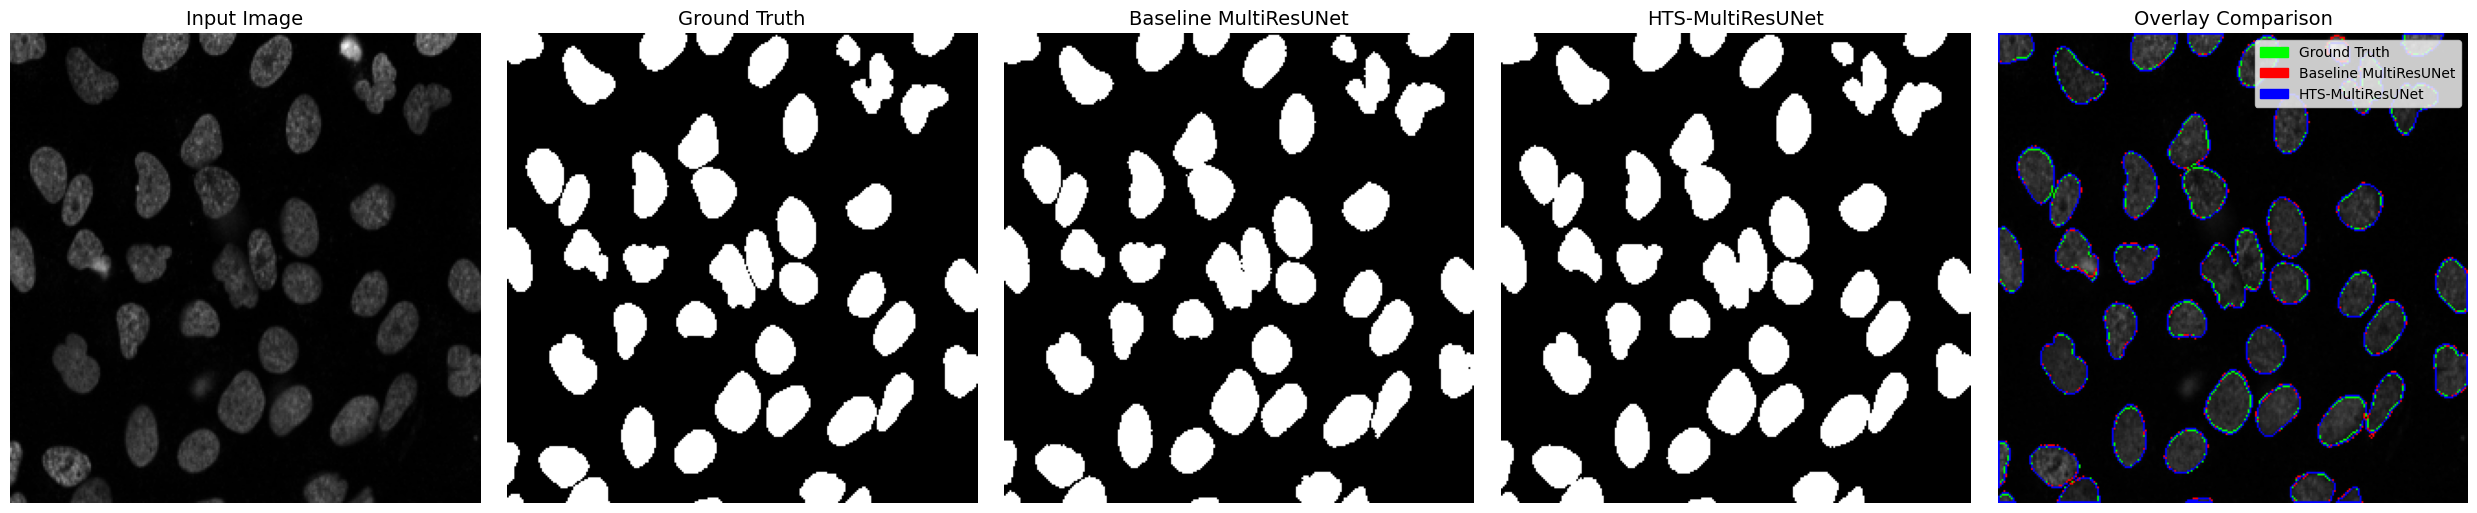

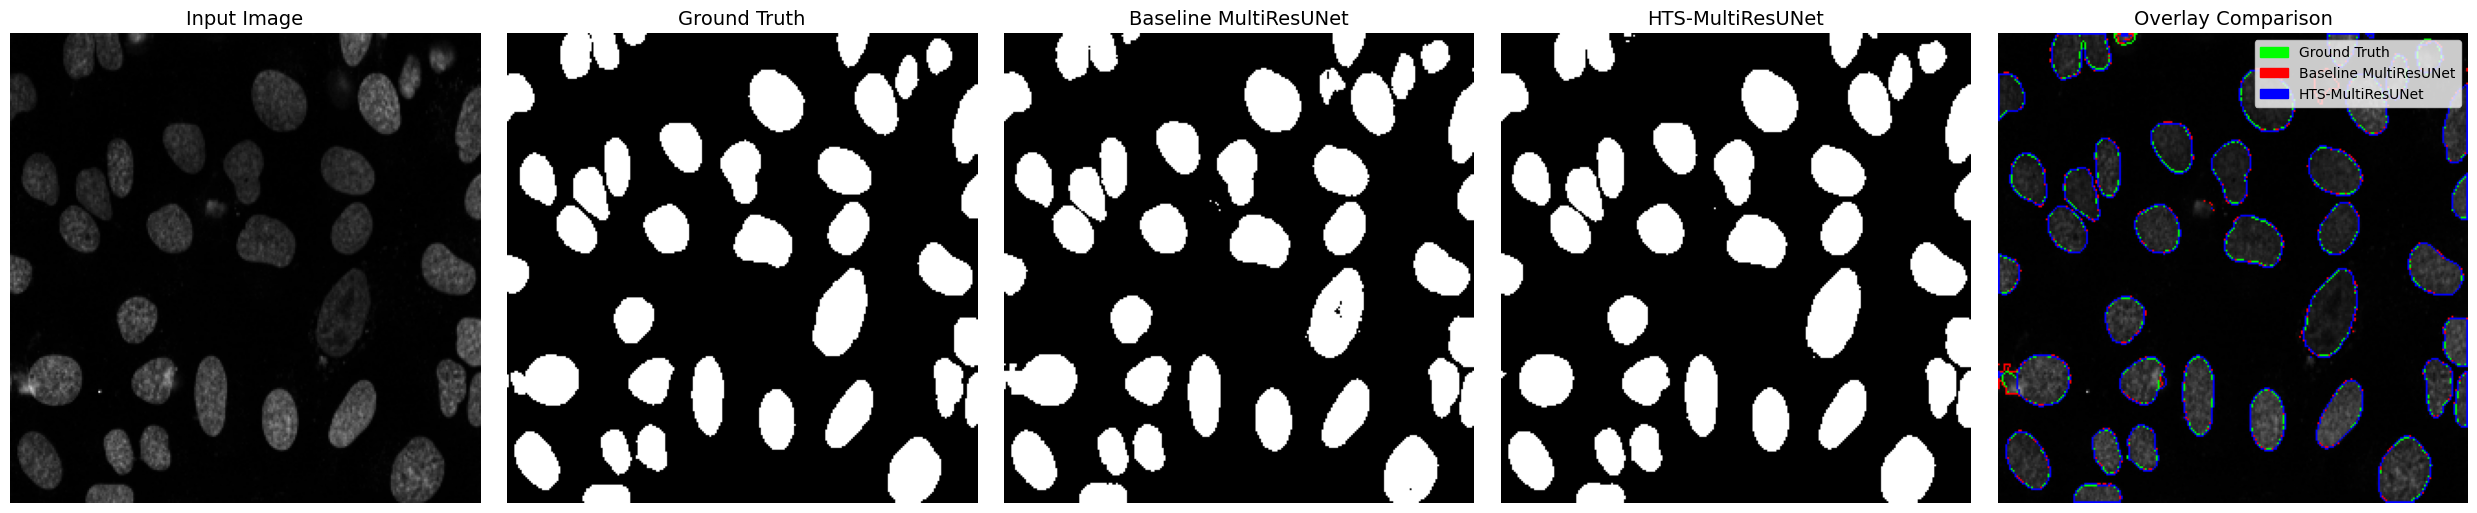

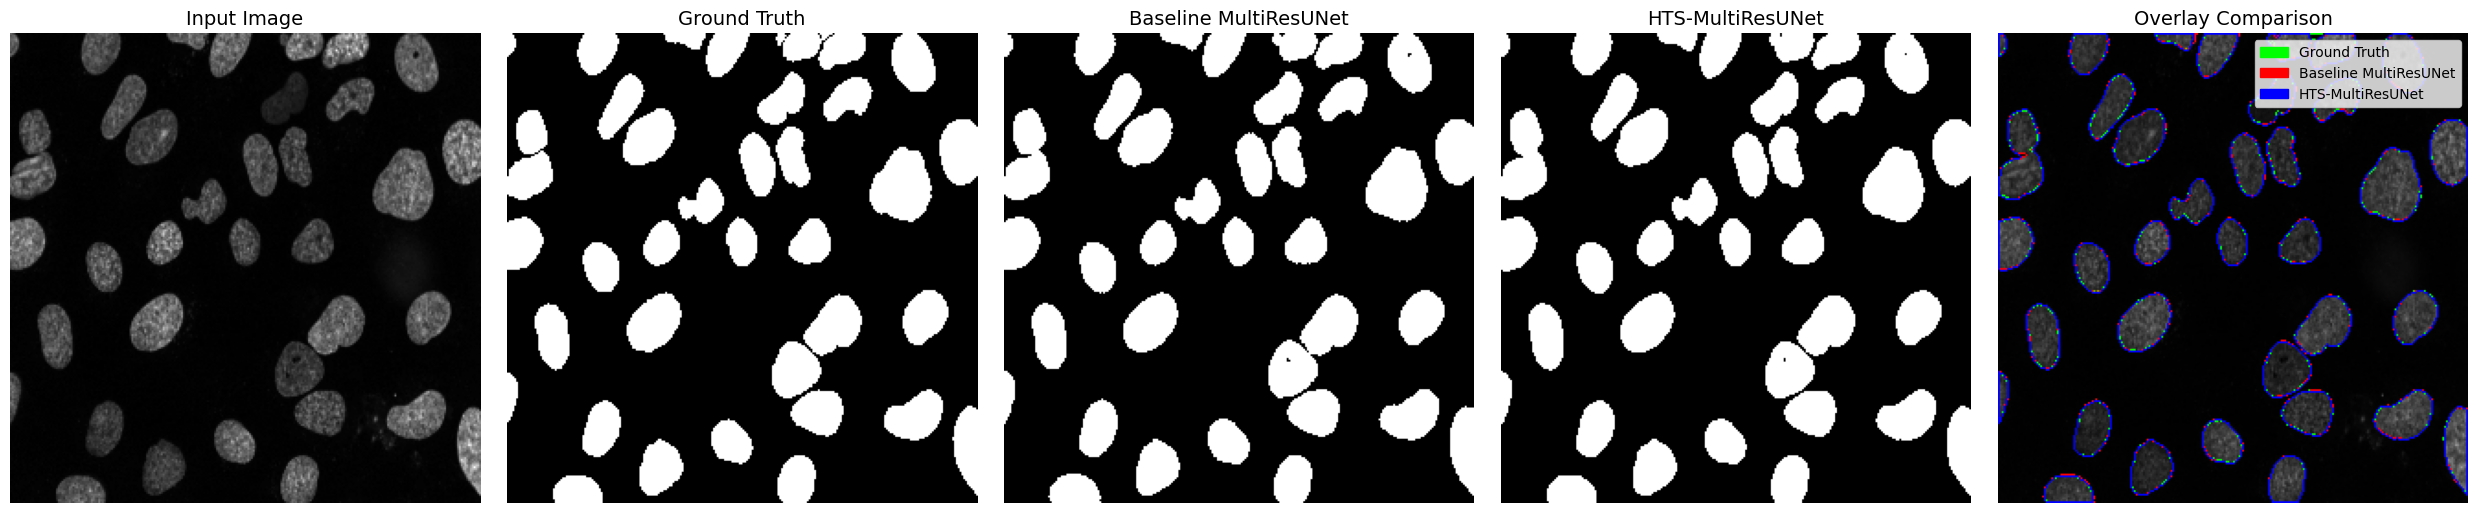


Đang tạo biểu đồ Learning Curve...


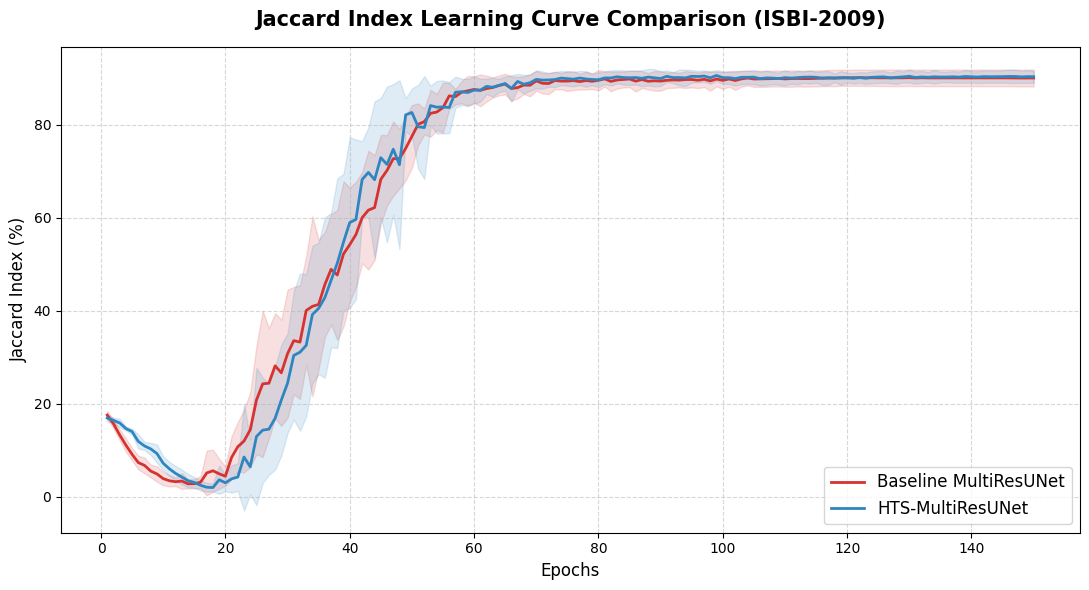


Đang tạo Bảng so sánh 5-Fold...


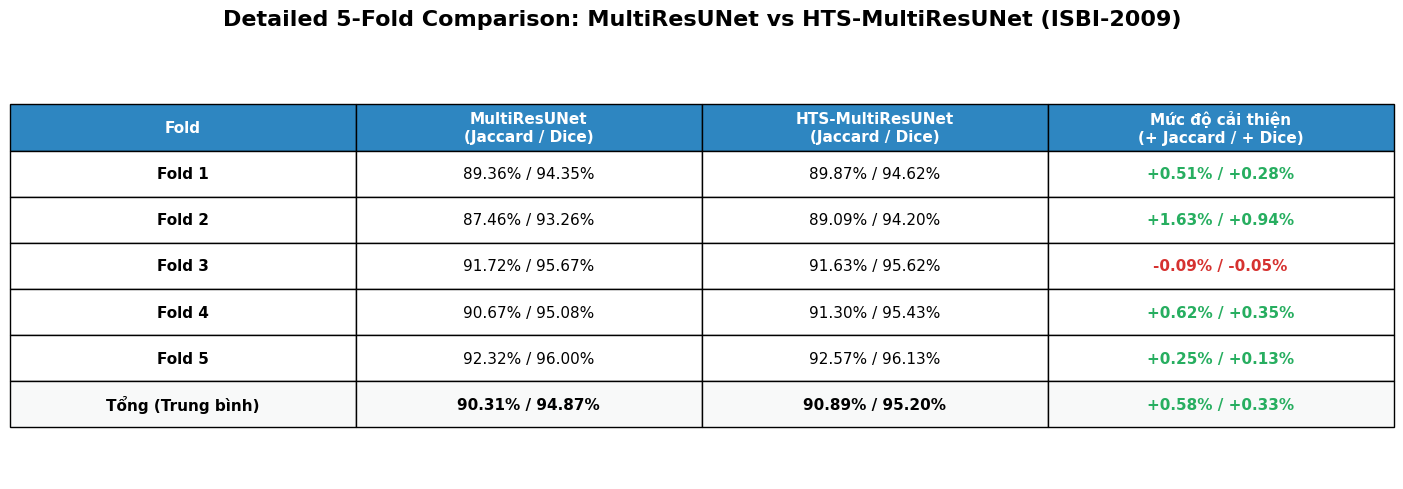


✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH! Đã nén kết quả vào file ISBI2009_Final_Report.zip


In [7]:
# ============================================================================
# 8. XUẤT ẢNH DEMO COMPARISON (OVERLAY CẢ 2 MÔ HÌNH TRÊN FOLD TỐT NHẤT)
# ============================================================================
print(f"\nThực hiện Demo trên Fold tốt nhất (Fold {best_fold_idx}) với Jaccard của HTS là {best_hts_jaccard*100:.2f}%")
train_idx_best, val_idx_best = list(kf.split(X))[best_fold_idx - 1]
X_val_best, Y_val_best = X[val_idx_best], Y[val_idx_best]

K.clear_session()
# Load Baseline
best_model_base = build_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)
best_model_base.load_weights(f'models_isbi2009/base_fold{best_fold_idx}.weights.h5')

# Load HTS
best_model_hts = build_hts_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)
best_model_hts.load_weights(f'models_isbi2009/hts_fold{best_fold_idx}.weights.h5')

show_comparison_demo(X_val_best, Y_val_best, best_model_base, best_model_hts, num_samples=3)

# ============================================================================
# 9. VẼ BIỂU ĐỒ LEARNING CURVE SO SÁNH 2 MÔ HÌNH
# ============================================================================
print("\nĐang tạo biểu đồ Learning Curve...")
base_data_jac = np.array([h.history['val_jacard'] for h in hist_base_list]) * 100
hts_data_jac = np.array([h.history['val_jacard'] for h in hist_hts_list]) * 100

plt.figure(figsize=(11, 6))
plt.plot(range(1, EPOCHS + 1), np.mean(base_data_jac, axis=0), label='Baseline MultiResUNet', color='#D63230', linewidth=2)
plt.fill_between(range(1, EPOCHS + 1), np.mean(base_data_jac, axis=0) - np.std(base_data_jac, axis=0), 
                 np.mean(base_data_jac, axis=0) + np.std(base_data_jac, axis=0), color='#D63230', alpha=0.15)

plt.plot(range(1, EPOCHS + 1), np.mean(hts_data_jac, axis=0), label='HTS-MultiResUNet', color='#2E86C1', linewidth=2)
plt.fill_between(range(1, EPOCHS + 1), np.mean(hts_data_jac, axis=0) - np.std(hts_data_jac, axis=0), 
                 np.mean(hts_data_jac, axis=0) + np.std(hts_data_jac, axis=0), color='#2E86C1', alpha=0.15)

plt.title('Jaccard Index Learning Curve Comparison (ISBI-2009)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Jaccard Index (%)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ISBI2009_Learning_Curve.png', dpi=300)
plt.show()

# ============================================================================
# 10. VẼ BẢNG SO SÁNH CHI TIẾT (5-FOLD)
# ============================================================================
print("\nĐang tạo Bảng so sánh 5-Fold...")
columns = ("Fold", "MultiResUNet\n(Jaccard / Dice)", "HTS-MultiResUNet\n(Jaccard / Dice)", "Mức độ cải thiện\n(+ Jaccard / + Dice)")
data = []

for i in range(5):
    b_j, b_d = jac_base[i], dice_base[i]
    h_j, h_d = jac_hts[i], dice_hts[i]
    diff_j, diff_d = h_j - b_j, h_d - b_d
    data.append([
        f"Fold {i+1}", 
        f"{b_j:.2f}% / {b_d:.2f}%", 
        f"{h_j:.2f}% / {h_d:.2f}%", 
        f"{'+' if diff_j>0 else ''}{diff_j:.2f}% / {'+' if diff_d>0 else ''}{diff_d:.2f}%"
    ])

# Tính trung bình
mean_b_j, mean_b_d = np.mean(jac_base), np.mean(dice_base)
mean_h_j, mean_h_d = np.mean(jac_hts), np.mean(dice_hts)
diff_mean_j, diff_mean_d = mean_h_j - mean_b_j, mean_h_d - mean_b_d

data.append([
    "Tổng (Trung bình)", 
    f"{mean_b_j:.2f}% / {mean_b_d:.2f}%", 
    f"{mean_h_j:.2f}% / {mean_h_d:.2f}%", 
    f"{'+' if diff_mean_j>0 else ''}{diff_mean_j:.2f}% / {'+' if diff_mean_d>0 else ''}{diff_mean_d:.2f}%"
])

# Vẽ bảng
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2E86C1') 
    elif row > 0:
        if col == 0: cell.set_text_props(weight='bold')
        if col == 3: 
            # Đổi màu xanh nếu tăng, đỏ nếu giảm
            cell_text = cell.get_text().get_text()
            if '+' in cell_text: cell.set_text_props(color='#27AE60', weight='bold')
            elif '-' in cell_text: cell.set_text_props(color='#D63230', weight='bold')
            else: cell.set_text_props(weight='bold')
        if row == 6: 
            cell.set_facecolor('#F8F9F9') 
            if col in [0, 1, 2]: cell.set_text_props(weight='bold', color='black')

plt.title('Detailed 5-Fold Comparison: MultiResUNet vs HTS-MultiResUNet (ISBI-2009)', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('Detailed_5Fold_Comparison_Table_ISBI2009.png', dpi=300, bbox_inches='tight')
plt.show()

# Đóng gói zip file
!zip -q -r ISBI2009_Final_Report.zip models_isbi2009/ *.png
print("\n✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH! Đã nén kết quả vào file ISBI2009_Final_Report.zip")

In [8]:
from IPython.display import FileLink

# Tạo link tải trực tiếp từ thư mục làm việc hiện tại
FileLink(r'ISBI2009_Final_Report.zip')

/kaggle/working/ISBI2009_Final_Report.zip